### Data loading

In [2]:
import pandas as pd
chronos = pd.read_csv("../data/CRISPR_gene_effect.csv",index_col=0).dropna()
chronos.columns = [g.split()[0] for g in chronos.columns]

### Histgrams (Figs. S1a)

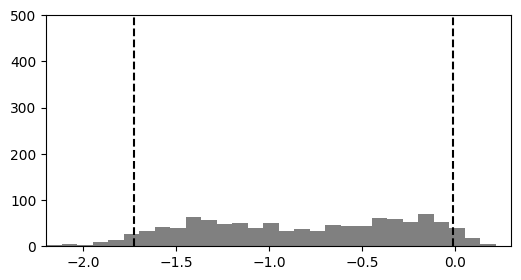

In [4]:
# Figure S1a
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,3))
bins = np.linspace(-2.2,0.3, 31)
gene="CCND1"
plt.hist(chronos[gene], bins=bins, color="gray")
plt.xlim(-2.2, 0.3)
plt.ylim(0, 500)

lower_5th = np.percentile(chronos[gene], 5)
upper_95th = np.percentile(chronos[gene], 95)
plt.axvline(lower_5th, color="black", linestyle="--")
plt.axvline(upper_95th, color="black", linestyle="--")
plt.show()

### Selectivity (Figs. S1b-e)

In [5]:
#Shimada et al., 2021 https://elifesciences.org/articles/57116
#Calculating Selectivity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from tqdm import tqdm
np.random.seed(42)
percentile = 5
rank = 100

X1 = percentile / 100
X2 = 1 - X1

D_G_X005,E_G_X005,E_G_X050,E_G_X095 = {},{},{},{}

# Calculate the 5th and 95th percentiles for each gene
for x in tqdm(chronos.columns):
    sorted_values = sorted(chronos[x])
    E_G_X005[x] = sorted_values[max(0, int(X1 * len(chronos.index)) - 1)]
    E_G_X095[x] = sorted_values[max(0, int(X2 * len(chronos.index)) - 1)]
    E_G_X050[x] = np.median(sorted_values)
    D_G_X005[x] = E_G_X005[x] - E_G_X095[x]

# Convert values to lists for spline fitting
X = np.array(list(E_G_X005.values()))
Y = np.array(list(E_G_X095.values()))

#Spline
# Sort X and Y based on X for spline fitting
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
Y_sorted = Y[sorted_indices]

# Use UnivariateSpline for a smoother fit
spline = UnivariateSpline(X_sorted, Y_sorted)
spline.set_smoothing_factor(150)  # Adjust this smoothing factor as needed

# Calculate Selectivity with the smoothed spline
sel = pd.DataFrame(index=["selectivity"], columns=chronos.columns)
for x in tqdm(sel.columns):
    sel[x] = (E_G_X095[x] - spline(E_G_X005[x])) / (spline(E_G_X005[x]) - E_G_X005[x])
selT = sel.T
selT['E005'] =  E_G_X005.values()

100%|██████████| 17386/17386 [00:09<00:00, 1766.37it/s]


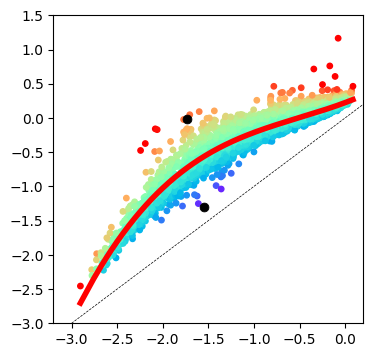

In [ ]:
# Fig. S1b
plt.figure(figsize=(4, 4))
plt.scatter(X, Y, s=15,cmap="rainbow",vmax=1, c=selT["selectivity"])

genels = ["CCND1", "H2AC15"]
for g in genels:
    plt.scatter(E_G_X005[g], E_G_X095[g], color="black", s=40, ec="black", linewidth=0.6)
plt.plot(X_sorted, spline(X_sorted), color='red', lw=4)
plt.axline((0, 0), (0.1, 0.1), color="black", lw=0.5, ls="--")
plt.xlim((-3.2,0.2))
plt.ylim((-3,1.5))
plt.show()

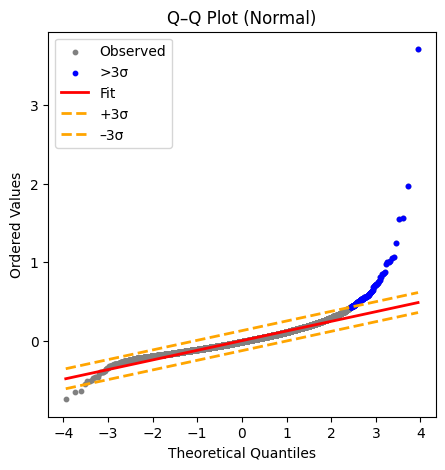

In [ ]:
#Figure S1c
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Generate Q-Q data and regression info
(osm, osr), (slope, intercept, r) = stats.probplot(selT.selectivity, dist="norm")

# Predicted (fitted) values
fitted = slope * osm + intercept

# Residuals
residuals = osr - fitted

# Compute standard deviation of residuals
sigma = np.std(residuals)

# Plot QQ + residuals
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# === Q–Q plot ===
axes.scatter(osm, osr, s=10, color='gray', label="Observed")

axes.scatter(osm[-129:],  # highlight >3σ points
                osr[-129:],
                s=10, color='blue', label='>3σ')
        

axes.plot(osm, fitted, color='red', lw=2, label="Fit")

# Add ±3σ lines (vertical shift from fitted line)
axes.plot(osm, fitted + 3 * sigma, color='orange', ls = '--',lw=2, label='+3σ')
axes.plot(osm, fitted - 3 * sigma, color='orange', ls = '--', lw=2, label='–3σ')

axes.set_title("Q–Q Plot (Normal)")
axes.set_xlabel("Theoretical Quantiles")
axes.set_ylabel("Ordered Values")
axes.legend()


plt.show()


c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


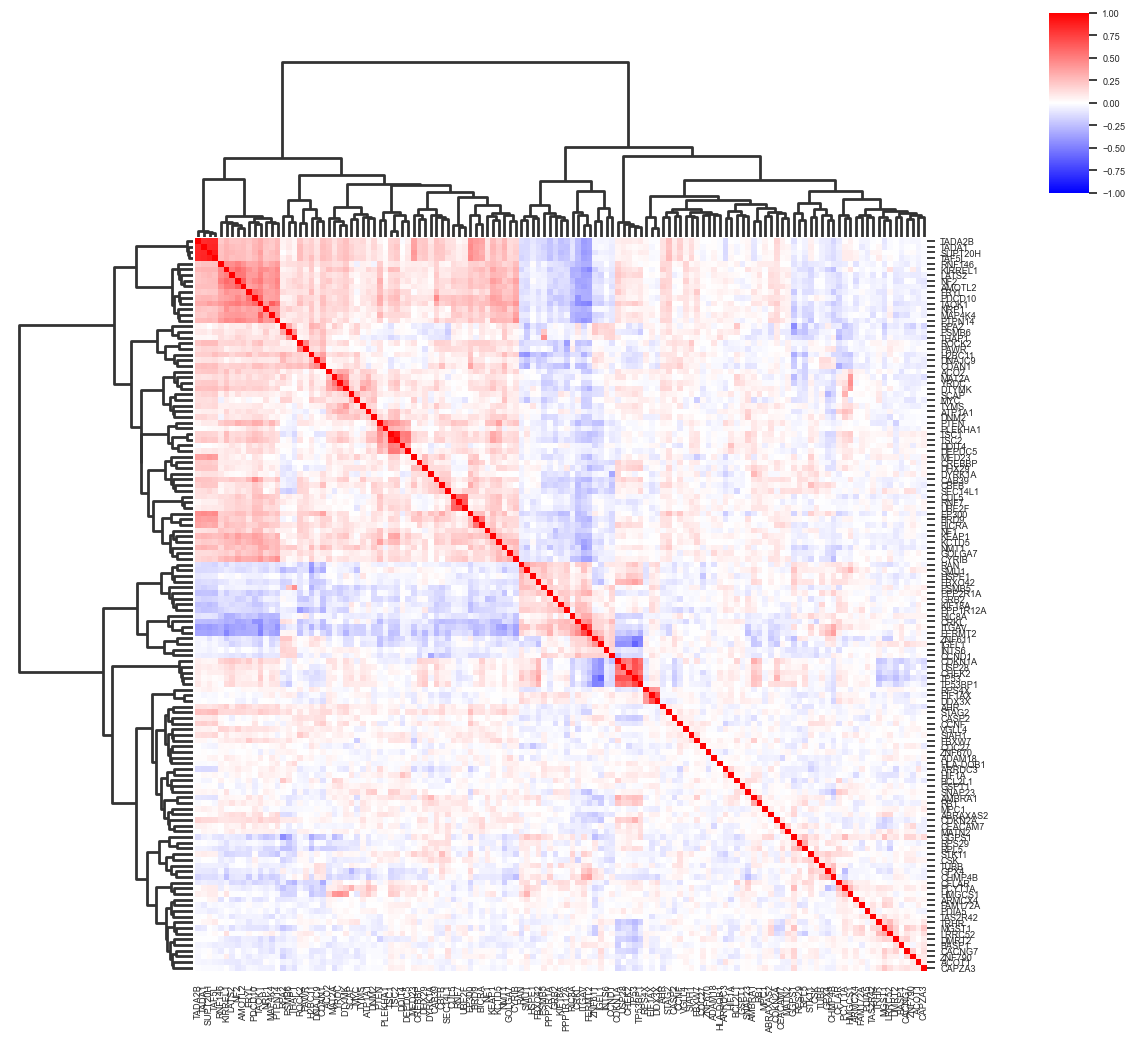

In [10]:
#Fig. S1d
import seaborn as sns
genes = selT.sort_values('selectivity',ascending=False)[:129].index
corr = chronos[genes].corr()
sns.set(font_scale= 0.6)
g = sns.clustermap(corr, cmap="bwr",vmax=1,vmin=-1, method = "ward",
               cbar_pos=(1.05, 0.85, 0.04, 0.18),
               tree_kws=dict(linewidths=2),figsize=(10,10),
               yticklabels=genes, xticklabels=genes)

plt.show()

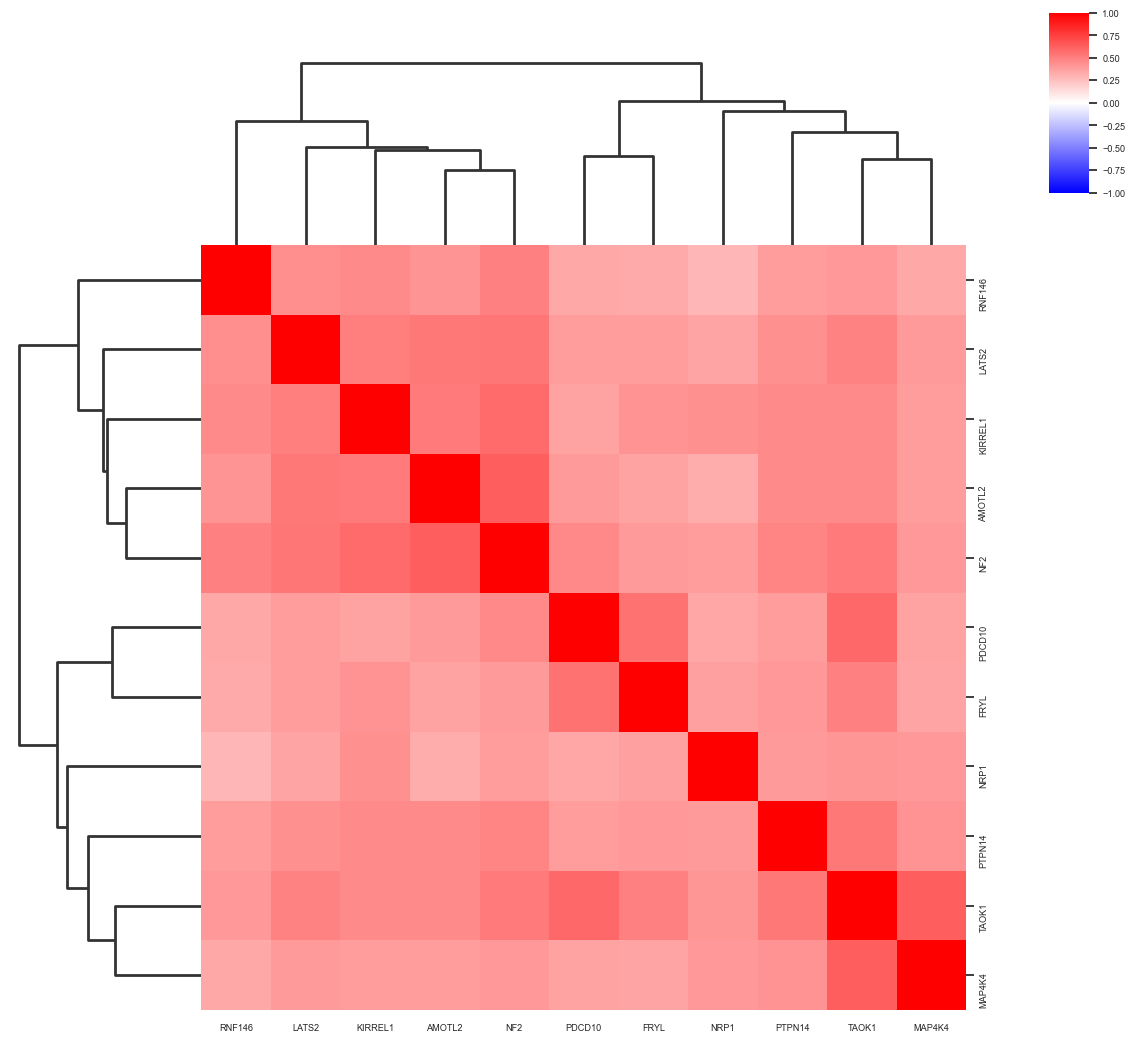

In [ ]:
#Fig. S1e
import seaborn as sns
#genes = ['TSC1','TSC2','PTEN','PLEKHA1','DDIT4', 'DEPDC5']
#genes = ['TADA2B', 'TADA1', 'SUPT20H', 'TAF5L']
#genes = ['CDKN1A', 'USP28', 'CHEK2', 'TP53']
genes = ['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL', 'LATS2', 'NRP1']
corr = chronos[genes].corr()
g = sns.clustermap(corr, cmap="bwr",vmax=1,vmin=-1, method = "ward",
               cbar_pos=(1.05, 0.85, 0.04, 0.18),
               tree_kws=dict(linewidths=2),figsize=(10,10),
               yticklabels=genes, xticklabels=genes)
plt.savefig('../result/Selectivity_clustermap129.svg')
plt.show()